# Importing Libraries 

In [160]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings('ignore')

sns.set_theme()
sns.set_context('notebook')
sns.set_style('whitegrid')
sns.set_palette('deep')

# Loading data set

In [161]:
data = pd.read_csv('bank.csv')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


# EDA, Data cleaning & preprocession

In [162]:
data.shape 

(11162, 17)

In [163]:
data.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
deposit        str
dtype: object

In [164]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [165]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [166]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')

<Axes: xlabel='deposit', ylabel='count'>

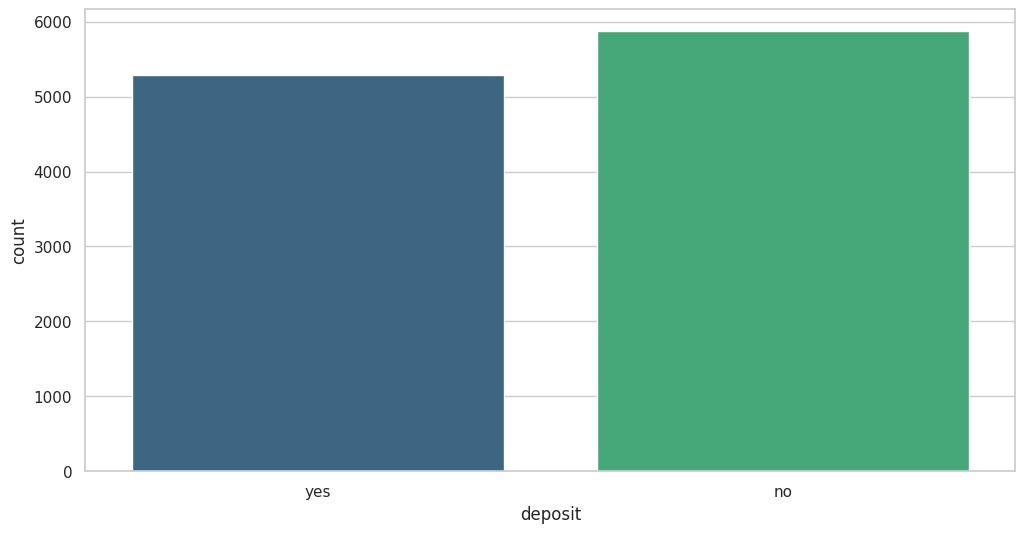

In [167]:
plt.figure(figsize=(12,6))
sns.countplot(x=data['deposit'],palette= 'viridis')

In [168]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [169]:
data = data.drop_duplicates()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>]], dtype=object)

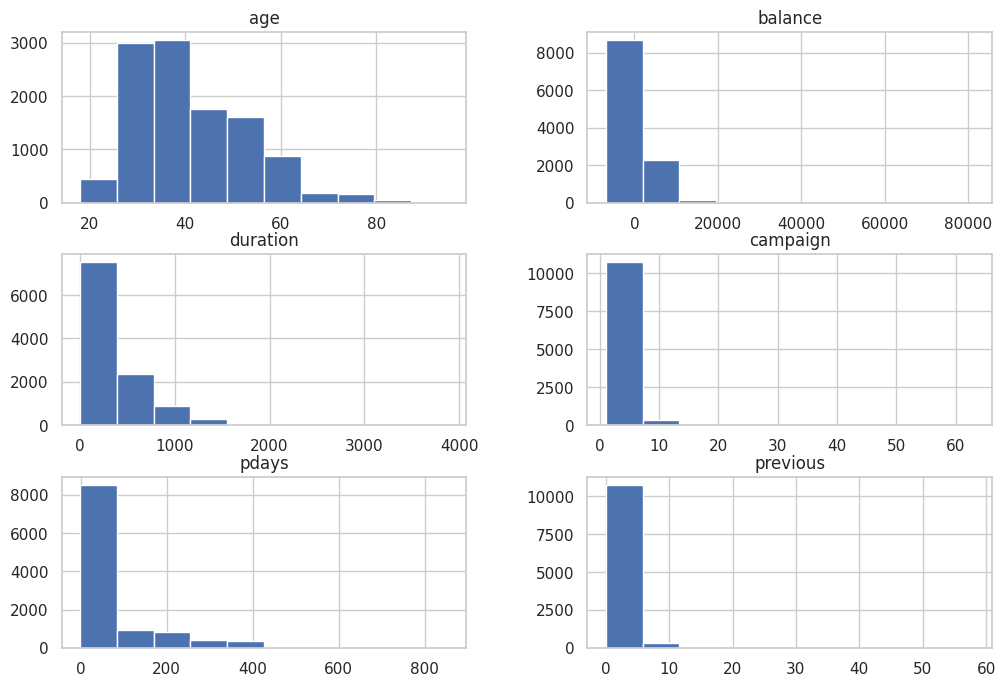

In [170]:
numerical = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

data[numerical].hist(figsize=(12,8))

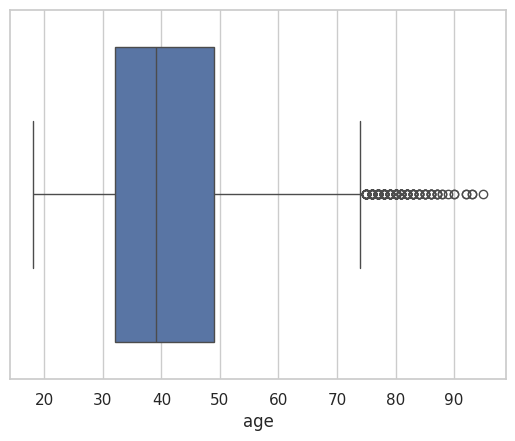

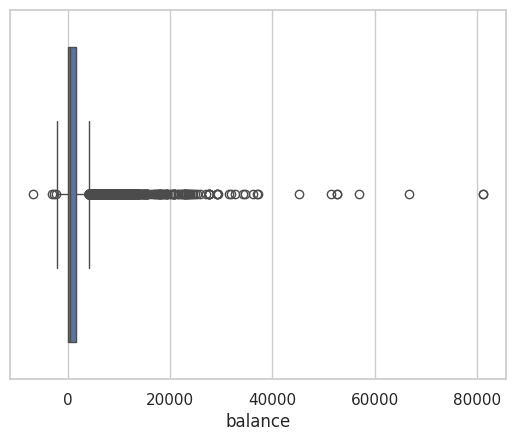

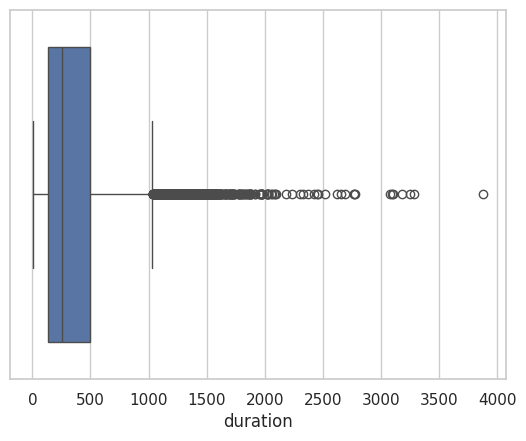

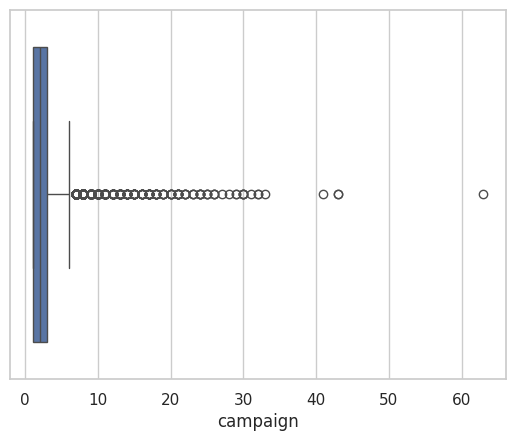

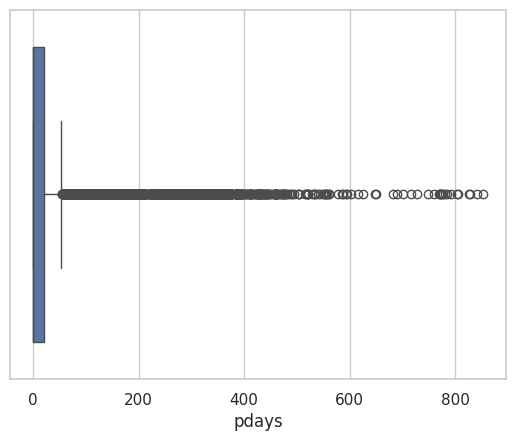

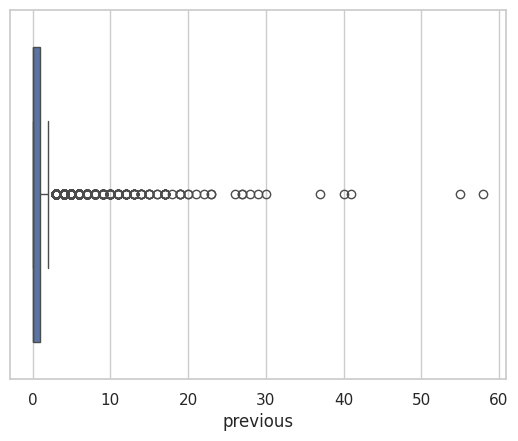

In [171]:
for col in numerical:
    sns.boxplot(x=data[col])
    plt.show()

**"Several numerical features contain outliers. Since these values represent genuine customer behavior rather than data entry errors, they were retained."**

<Axes: >

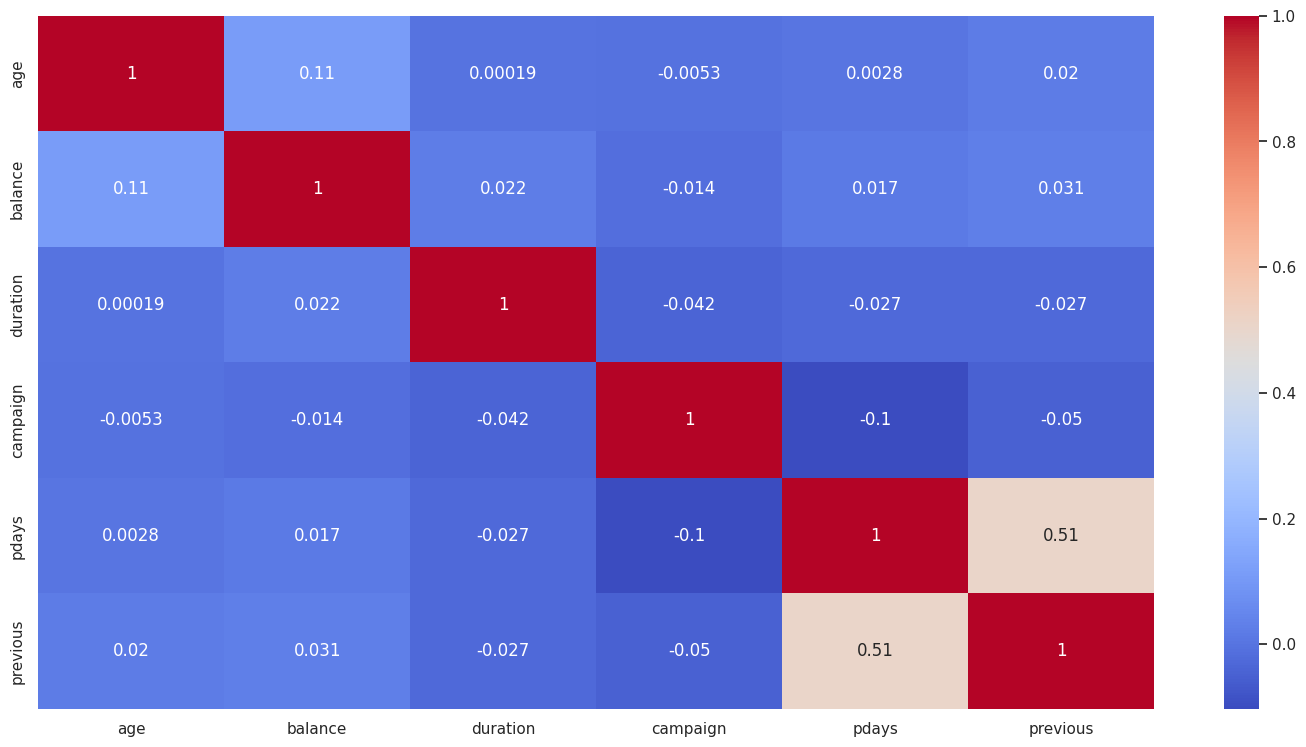

In [172]:
plt.figure(figsize=(18,9))
sns.heatmap(data[numerical].corr(),
            annot=True,
            cmap="coolwarm")

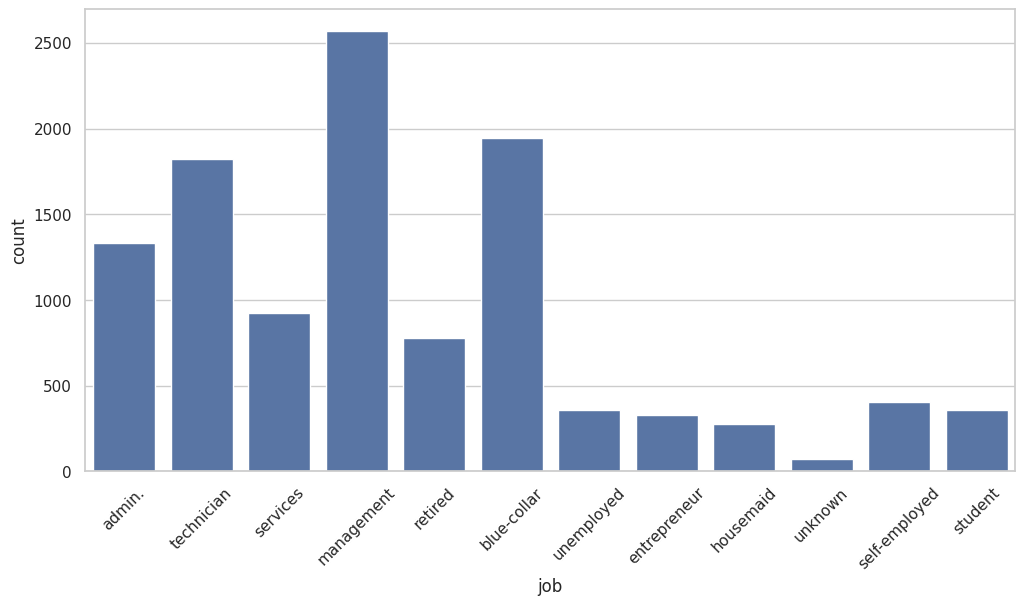

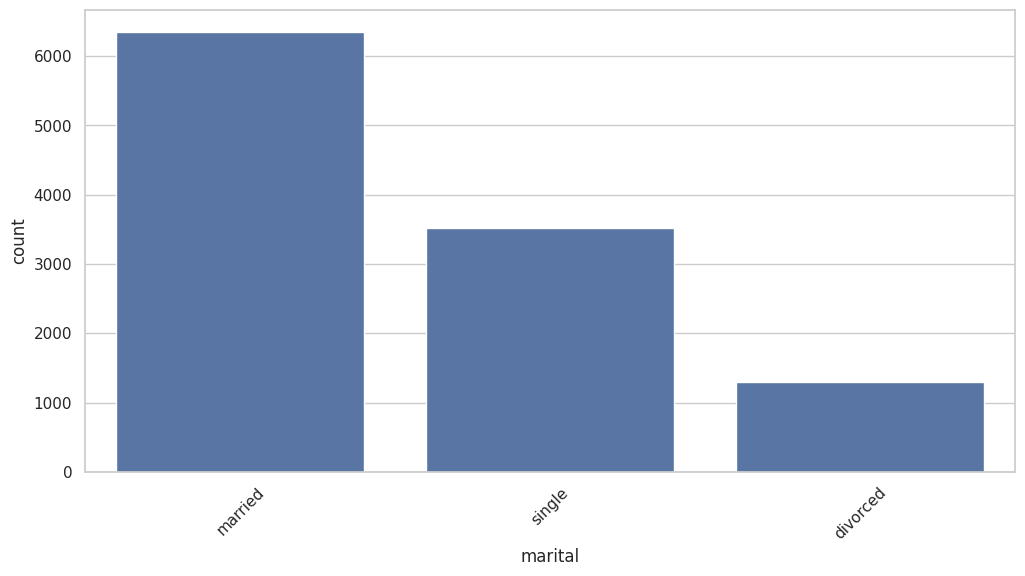

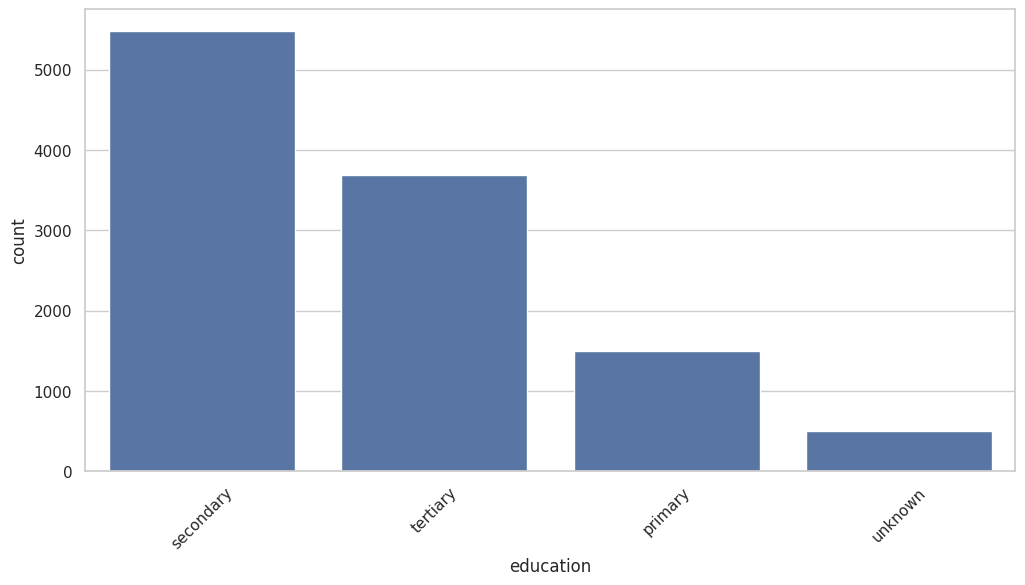

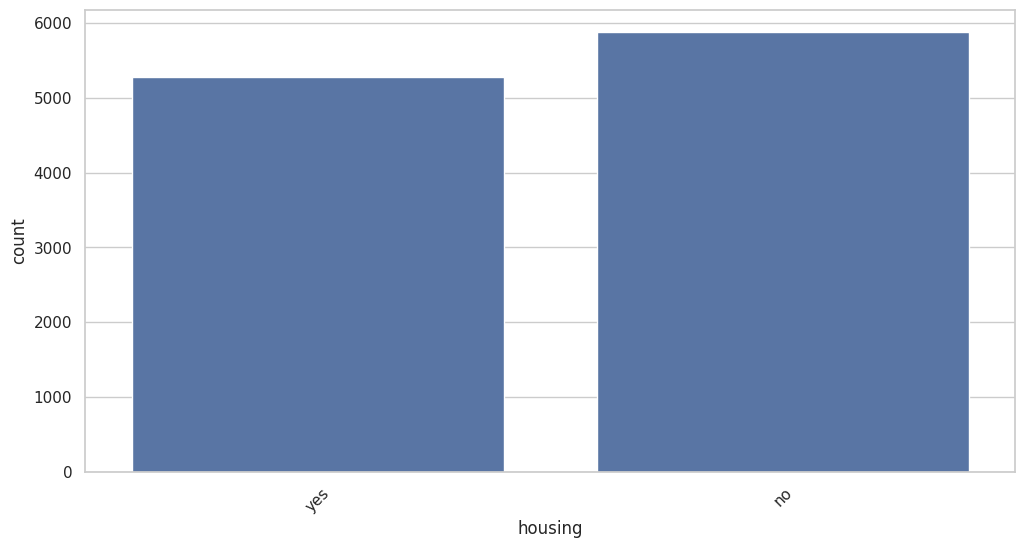

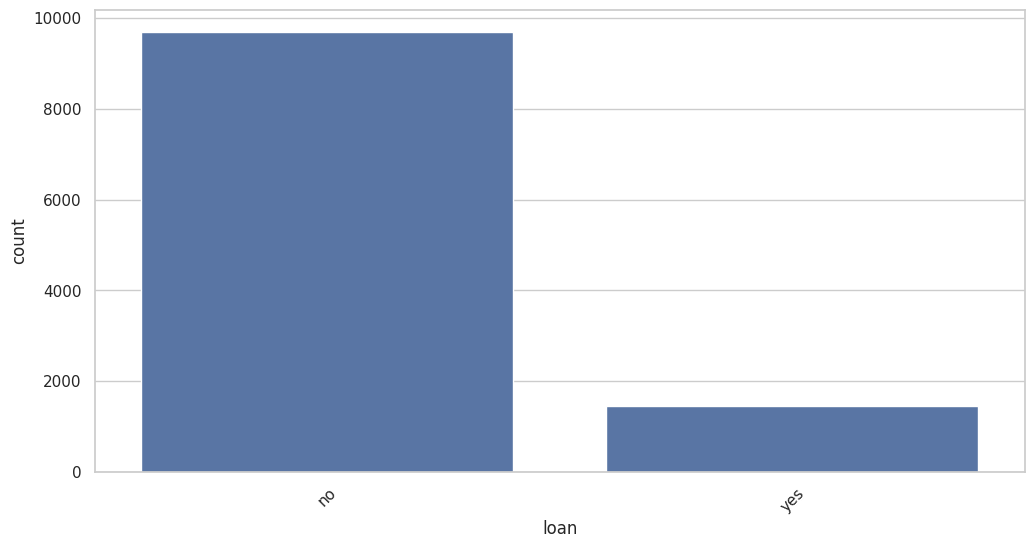

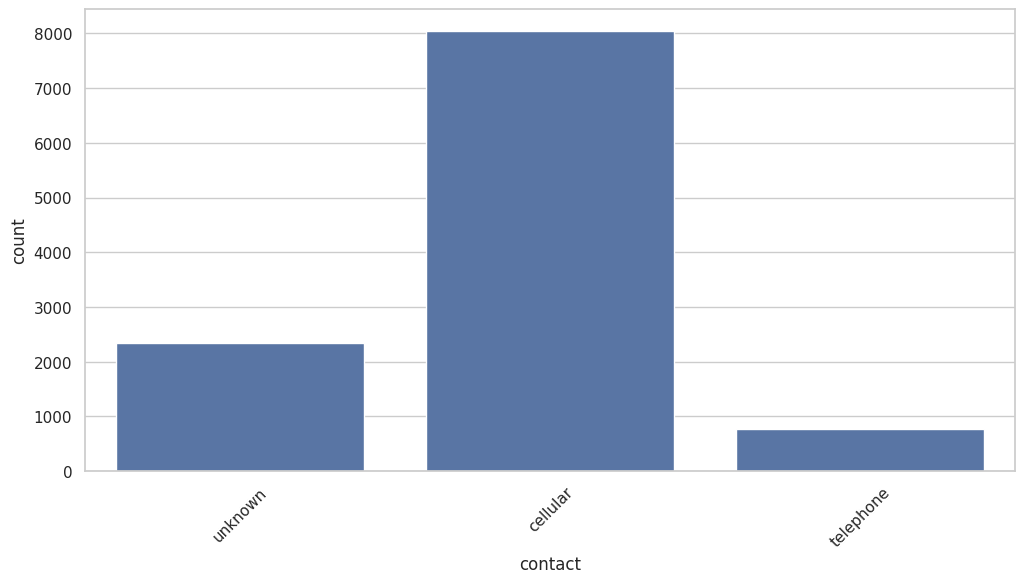

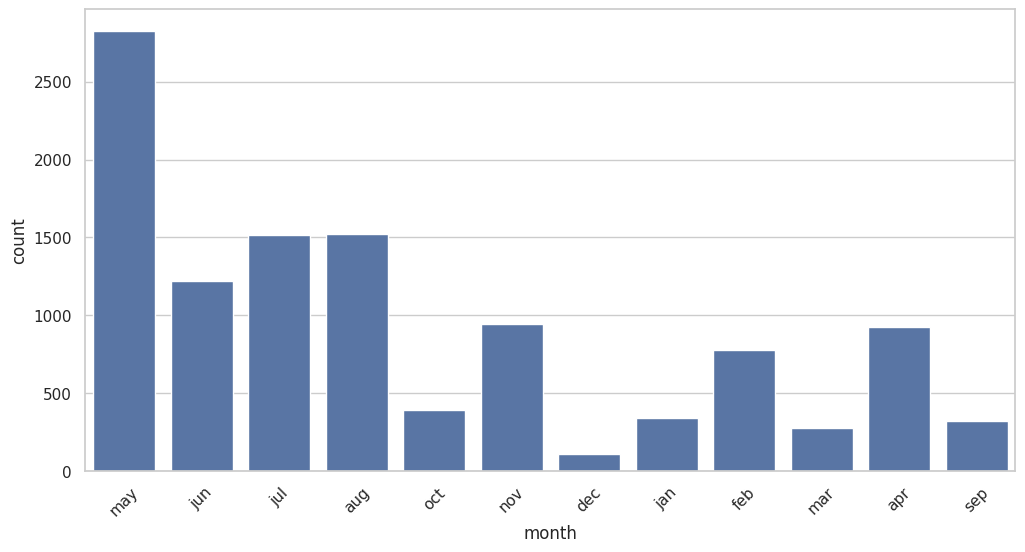

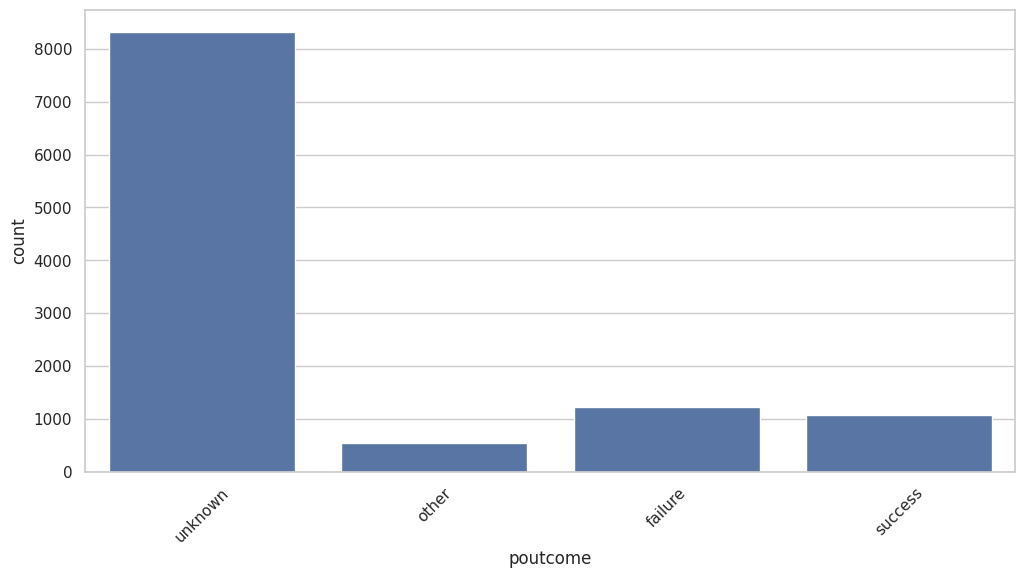

In [173]:
categorical = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]
for col in categorical:
    plt.figure(figsize=(12,6))
    sns.countplot(x = data[col])
    plt.xticks(rotation=45)

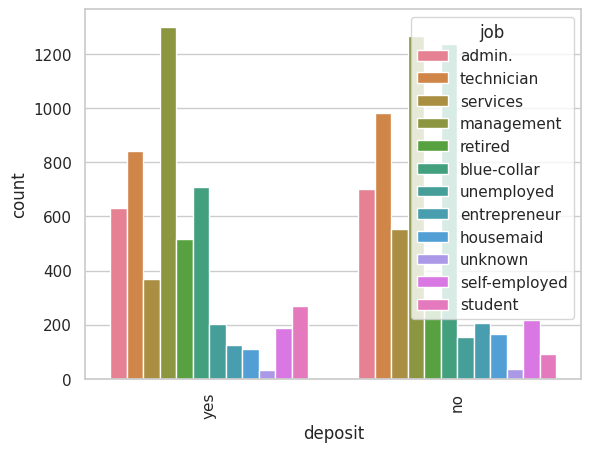

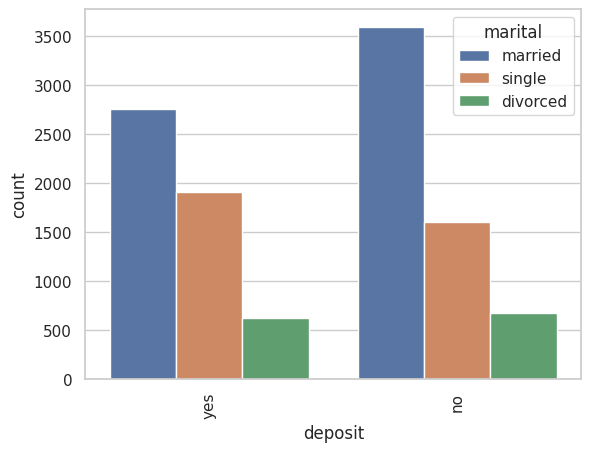

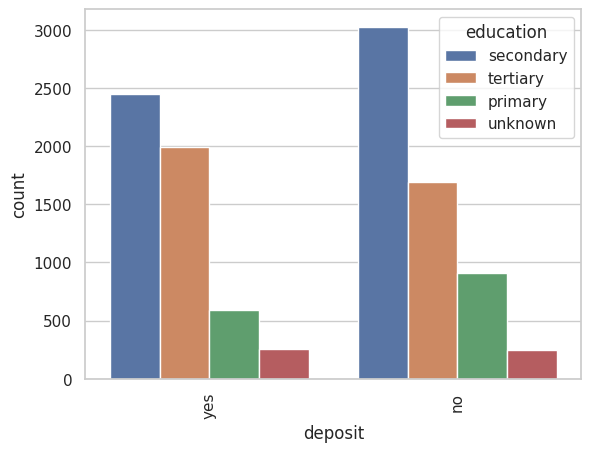

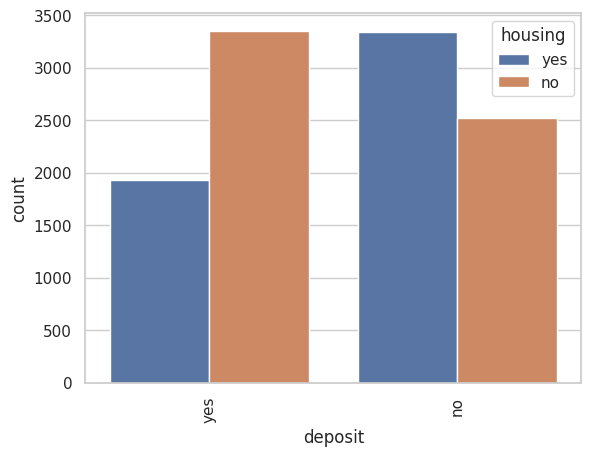

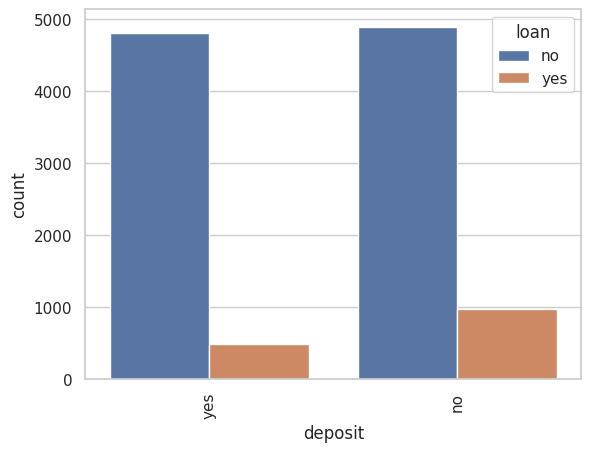

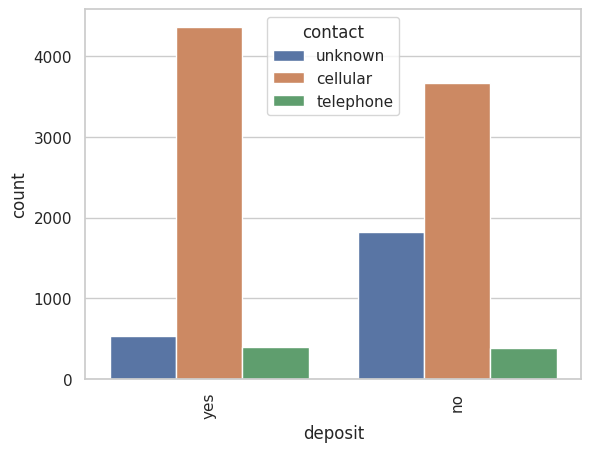

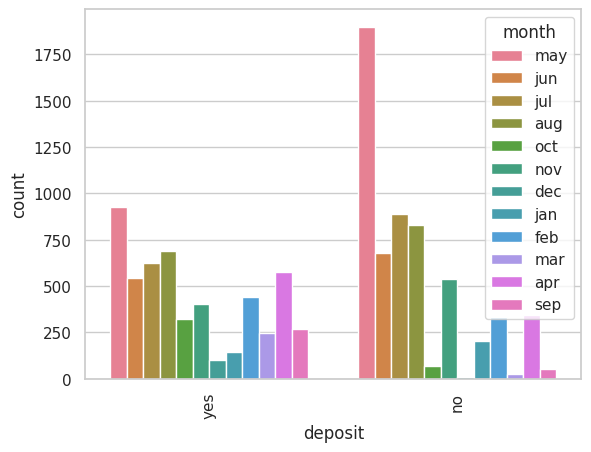

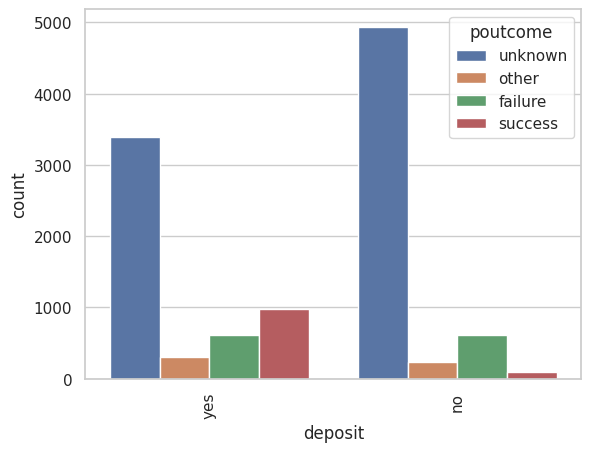

In [174]:
for col in categorical:
    plt.Figure(figsize=(18,9))
    sns.countplot(x=data['deposit'],
                hue=data[col])
    plt.xticks(rotation=90)
    plt.show()

In [175]:

for col in categorical:
    print(f"========== {col} ==========")
    print(data[col].value_counts())

========== job ==========
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
========== marital ==========
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
========== education ==========
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
========== housing ==========
housing
no     5881
yes    5281
Name: count, dtype: int64
========== loan ==========
loan
no     9702
yes    1460
Name: count, dtype: int64
========== contact ==========
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
========== month ==========
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan    

In [176]:
data[data['job'] == 'unknown']['job'] = 'others'

In [177]:
data['loan'] = data['loan'].map({
    'yes': 1,
    'no' : 0
}, inplace = True)
data['housing'] = data['housing'].map({
    'yes': 1,
    'no' : 0
}, inplace = True)

data['previous_loans'] = data['previous_loans'] = data['loan'] + data['housing'] 

data.drop(columns=['loan','housing'], inplace = True)

In [178]:
data['default'] = data['default'].map({
    'yes':1,
    'no':0
}, inplace = True)

In [179]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             11162 non-null  int64
 1   job             11162 non-null  str  
 2   marital         11162 non-null  str  
 3   education       11162 non-null  str  
 4   default         11162 non-null  int64
 5   balance         11162 non-null  int64
 6   contact         11162 non-null  str  
 7   day             11162 non-null  int64
 8   month           11162 non-null  str  
 9   duration        11162 non-null  int64
 10  campaign        11162 non-null  int64
 11  pdays           11162 non-null  int64
 12  previous        11162 non-null  int64
 13  poutcome        11162 non-null  str  
 14  deposit         11162 non-null  str  
 15  previous_loans  11162 non-null  int64
dtypes: int64(9), str(7)
memory usage: 1.4 MB


In [180]:
data.describe()

,age,default,balance,day,duration,campaign,pdays,previous,previous_loans
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,0.015051,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557,0.603924
std,11.913369,0.121761,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007,0.623578
min,18.000000,0.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,0.000000
25%,32.000000,0.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,0.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000,1.000000
75%,49.000000,0.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000,1.000000
max,95.000000,1.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000,2.000000


In [181]:
data["previous_contact"] = (
    data["pdays"] != -1
).astype(int)

In [182]:
data.head()

,age,job,marital,education,default,balance,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,previous_loans,previous_contact
0,59,admin.,married,secondary,0,2343,unknown,5,may,1042,1,-1,0,unknown,yes,1,0
1,56,admin.,married,secondary,0,45,unknown,5,may,1467,1,-1,0,unknown,yes,0,0
2,41,technician,married,secondary,0,1270,unknown,5,may,1389,1,-1,0,unknown,yes,1,0
3,55,services,married,secondary,0,2476,unknown,5,may,579,1,-1,0,unknown,yes,1,0
4,54,admin.,married,tertiary,0,184,unknown,5,may,673,2,-1,0,unknown,yes,0,0


In [183]:
cols =  ['job','marital','education','contact','month','poutcome']

data = pd.get_dummies(data=data,columns= cols, dtype=int)

data['deposit'] = data['deposit'].map({
    'yes':1,
    'no':0
}, inplace = True)

In [184]:
data.head()

,age,default,balance,day,duration,campaign,pdays,previous,deposit,previous_loans,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,5,1042,1,-1,0,1,1,...,0,0,1,0,0,0,0,0,0,1
1,56,0,45,5,1467,1,-1,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,41,0,1270,5,1389,1,-1,0,1,1,...,0,0,1,0,0,0,0,0,0,1
3,55,0,2476,5,579,1,-1,0,1,1,...,0,0,1,0,0,0,0,0,0,1
4,54,0,184,5,673,2,-1,0,1,0,...,0,0,1,0,0,0,0,0,0,1


# Test Train Split

In [186]:
X = data.drop(['deposit'], axis=1)
y = data['deposit']

In [187]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [189]:
X_train

,age,default,balance,day,duration,campaign,pdays,previous,previous_loans,previous_contact,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
337,52,0,2269,20,1210,1,-1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
6221,40,0,34,6,350,2,344,1,1,1,...,0,0,1,0,0,0,1,0,0,0
4345,35,0,1731,31,361,4,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2650,31,0,924,7,231,1,94,3,0,1,...,0,0,0,0,0,1,0,0,1,0
5156,35,0,1015,5,406,2,-1,0,1,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,47,0,761,11,80,2,-1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
5191,28,0,159,16,449,2,33,4,0,1,...,0,0,0,1,0,0,0,0,1,0
5390,35,0,1144,20,197,13,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
860,51,0,746,25,372,5,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Feature Scalling

In [191]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

In [193]:
X_train[['age','balance','day','duration','campaign','pdays','previous']] = scalar.fit_transform(X_train[['age','balance','day','duration','campaign','pdays','previous']] )
X_test[['age','balance','day','duration','campaign','pdays','previous']] = scalar.transform(X_test[['age','balance','day','duration','campaign','pdays','previous']] )


In [194]:
X_train

,age,default,balance,day,duration,campaign,pdays,previous,previous_loans,previous_contact,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
337,0.909789,0,0.222228,0.523849,2.427045,-0.551785,-0.473005,-0.374295,0,0,...,1,0,0,0,0,0,0,0,0,1
6221,-0.104799,0,-0.466623,-1.144120,-0.057799,-0.182513,2.719561,0.089650,1,1,...,0,0,1,0,0,0,1,0,0,0
4345,-0.527543,0,0.056411,1.834396,-0.026016,0.556032,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1
2650,-0.865739,0,-0.192315,-1.024979,-0.401632,-0.551785,0.406107,1.017540,0,1,...,0,0,0,0,0,1,0,0,1,0
5156,-0.527543,0,-0.164268,-1.263260,0.104005,-0.182513,-0.473005,-0.374295,1,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.487044,0,-0.242554,-0.548417,-0.837924,-0.182513,-0.473005,-0.374295,1,0,...,0,0,0,0,0,0,0,0,0,1
5191,-1.119386,0,-0.428096,0.047287,0.228247,-0.182513,-0.158375,1.481485,0,1,...,0,0,0,1,0,0,0,0,1,0
5390,-0.527543,0,-0.124509,0.523849,-0.499870,3.879485,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1
860,0.825240,0,-0.247177,1.119552,0.005767,0.925305,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1


In [195]:
X_test

,age,default,balance,day,duration,campaign,pdays,previous,previous_loans,previous_contact,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
5527,2.008925,0,-0.247793,-1.263260,-0.543210,-0.551785,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1
4541,-0.273897,0,0.024357,0.047287,2.753542,2.402395,-0.473005,-0.374295,0,0,...,1,0,0,0,0,0,0,0,0,1
1964,-0.527543,0,1.052548,-0.190995,0.248473,-0.551785,2.312393,0.089650,1,1,...,0,0,1,0,0,0,1,0,0,0
5007,0.487044,0,2.059165,-0.905839,1.196181,-0.182513,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1
8928,-0.527543,0,-0.023107,-0.429276,-0.826367,0.186760,-0.473005,-0.374295,1,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5799,3.023512,0,-0.280155,0.047287,-0.702124,1.663850,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1
5950,0.317946,0,-0.477102,0.762131,-0.817699,0.556032,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1
10479,-0.358445,0,-0.345496,0.523849,-0.719461,-0.551785,-0.473005,-0.374295,1,0,...,0,0,1,0,0,0,0,0,0,1
1728,1.163436,0,-0.434261,1.715256,-0.372738,-0.551785,-0.473005,-0.374295,0,0,...,0,0,0,0,0,0,0,0,0,1


# Logistic Regression Model 

In [196]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression()

LR_model.fit(X_train,y_train)

LR_predictions = LR_model.predict(X_test)

LR_predictions

array([0, 1, 1, ..., 0, 1, 1], shape=(3684,))

# LR model Evaluation

In [199]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix

In [200]:
confusion_matrix(LR_predictions, y_test)

array([[1633,  380],
       [ 284, 1387]])

In [201]:
LR_accuracy = accuracy_score(LR_predictions, y_test)
LR_precision = precision_score(LR_predictions, y_test)
LR_recall = recall_score(LR_predictions, y_test)
LR_f1 = f1_score(LR_predictions, y_test)

In [202]:
print(f'''LR_accuracy: {LR_accuracy*100} %
      
LR_precision: {LR_precision*100} %

LR_recall: {LR_recall*100} %

LR_f1: {LR_f1*100} %''')

LR_accuracy: 81.97611292073833 %

LR_precision: 78.49462365591397 %

LR_recall: 83.00418910831837 %

LR_f1: 80.68644560791157 %


# KNN-Classifier model

In [215]:
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier(n_neighbors= 9)

KNN_model.fit(X_train,y_train)

KNN_predictions = KNN_model.predict(X_test)

KNN_predictions

array([1, 1, 0, ..., 0, 1, 1], shape=(3684,))

# KNN model evaluation

In [216]:
KNN_accuracy = accuracy_score(KNN_predictions, y_test)
KNN_precision = precision_score(KNN_predictions, y_test)
KNN_recall = recall_score(KNN_predictions, y_test)
KNN_f1 = f1_score(KNN_predictions, y_test)

In [220]:
print(f'''KNN_accuracy: {KNN_accuracy*100} %
      
KNN_precision: {KNN_precision*100} %

KNN_recall: {KNN_recall*100} %

KNN_f1: {KNN_f1*100} %''')

KNN_accuracy: 81.32464712269272 %

KNN_precision: 76.28749292586305 %

KNN_recall: 83.36425479282622 %

KNN_f1: 79.66903073286052 %


# Naive Bayes model

In [218]:
from sklearn.naive_bayes import GaussianNB

NB_model = GaussianNB()

NB_model.fit(X_train,y_train)

NB_predictions = NB_model.predict(X_test)

NB_predictions

array([0, 0, 0, ..., 0, 0, 0], shape=(3684,))

# NB model evaluation

In [219]:
NB_accuracy = accuracy_score(NB_predictions, y_test)
NB_precision = precision_score(NB_predictions, y_test)
NB_recall = recall_score(NB_predictions, y_test)
NB_f1 = f1_score(NB_predictions, y_test)

In [221]:
print(f'''NB_accuracy: {NB_accuracy*100} %
      
NB_precision: {NB_precision*100} %

NB_recall: {NB_recall*100} %

NB_f1: {NB_f1*100} %''')

NB_accuracy: 70.57546145494028 %

NB_precision: 55.291454442558006 %

NB_recall: 76.86860739575138 %

NB_f1: 64.31863067807768 %


# Model performance comparison table 

In [224]:
comparison_df = pd.DataFrame(
    {
        'accuracy' : [LR_accuracy,KNN_accuracy,NB_accuracy],
        'precision' : [LR_precision,KNN_precision,NB_precision],
        'recall' :[LR_recall,KNN_recall,NB_recall],
        'f1_score' : [LR_f1,KNN_f1,NB_f1]
    },
    index= ['LogisticRegression','KNN-Classifier','NB_Gaussian']
)

comparison_df

,accuracy,precision,recall,f1_score
LogisticRegression,0.819761,0.784946,0.830042,0.806864
KNN-Classifier,0.813246,0.762875,0.833643,0.796690
NB_Gaussian,0.705755,0.552915,0.768686,0.643186
